In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('Advertising.csv', index_col = 0)
df.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


Text(0.5, 0, 'Newspaper')

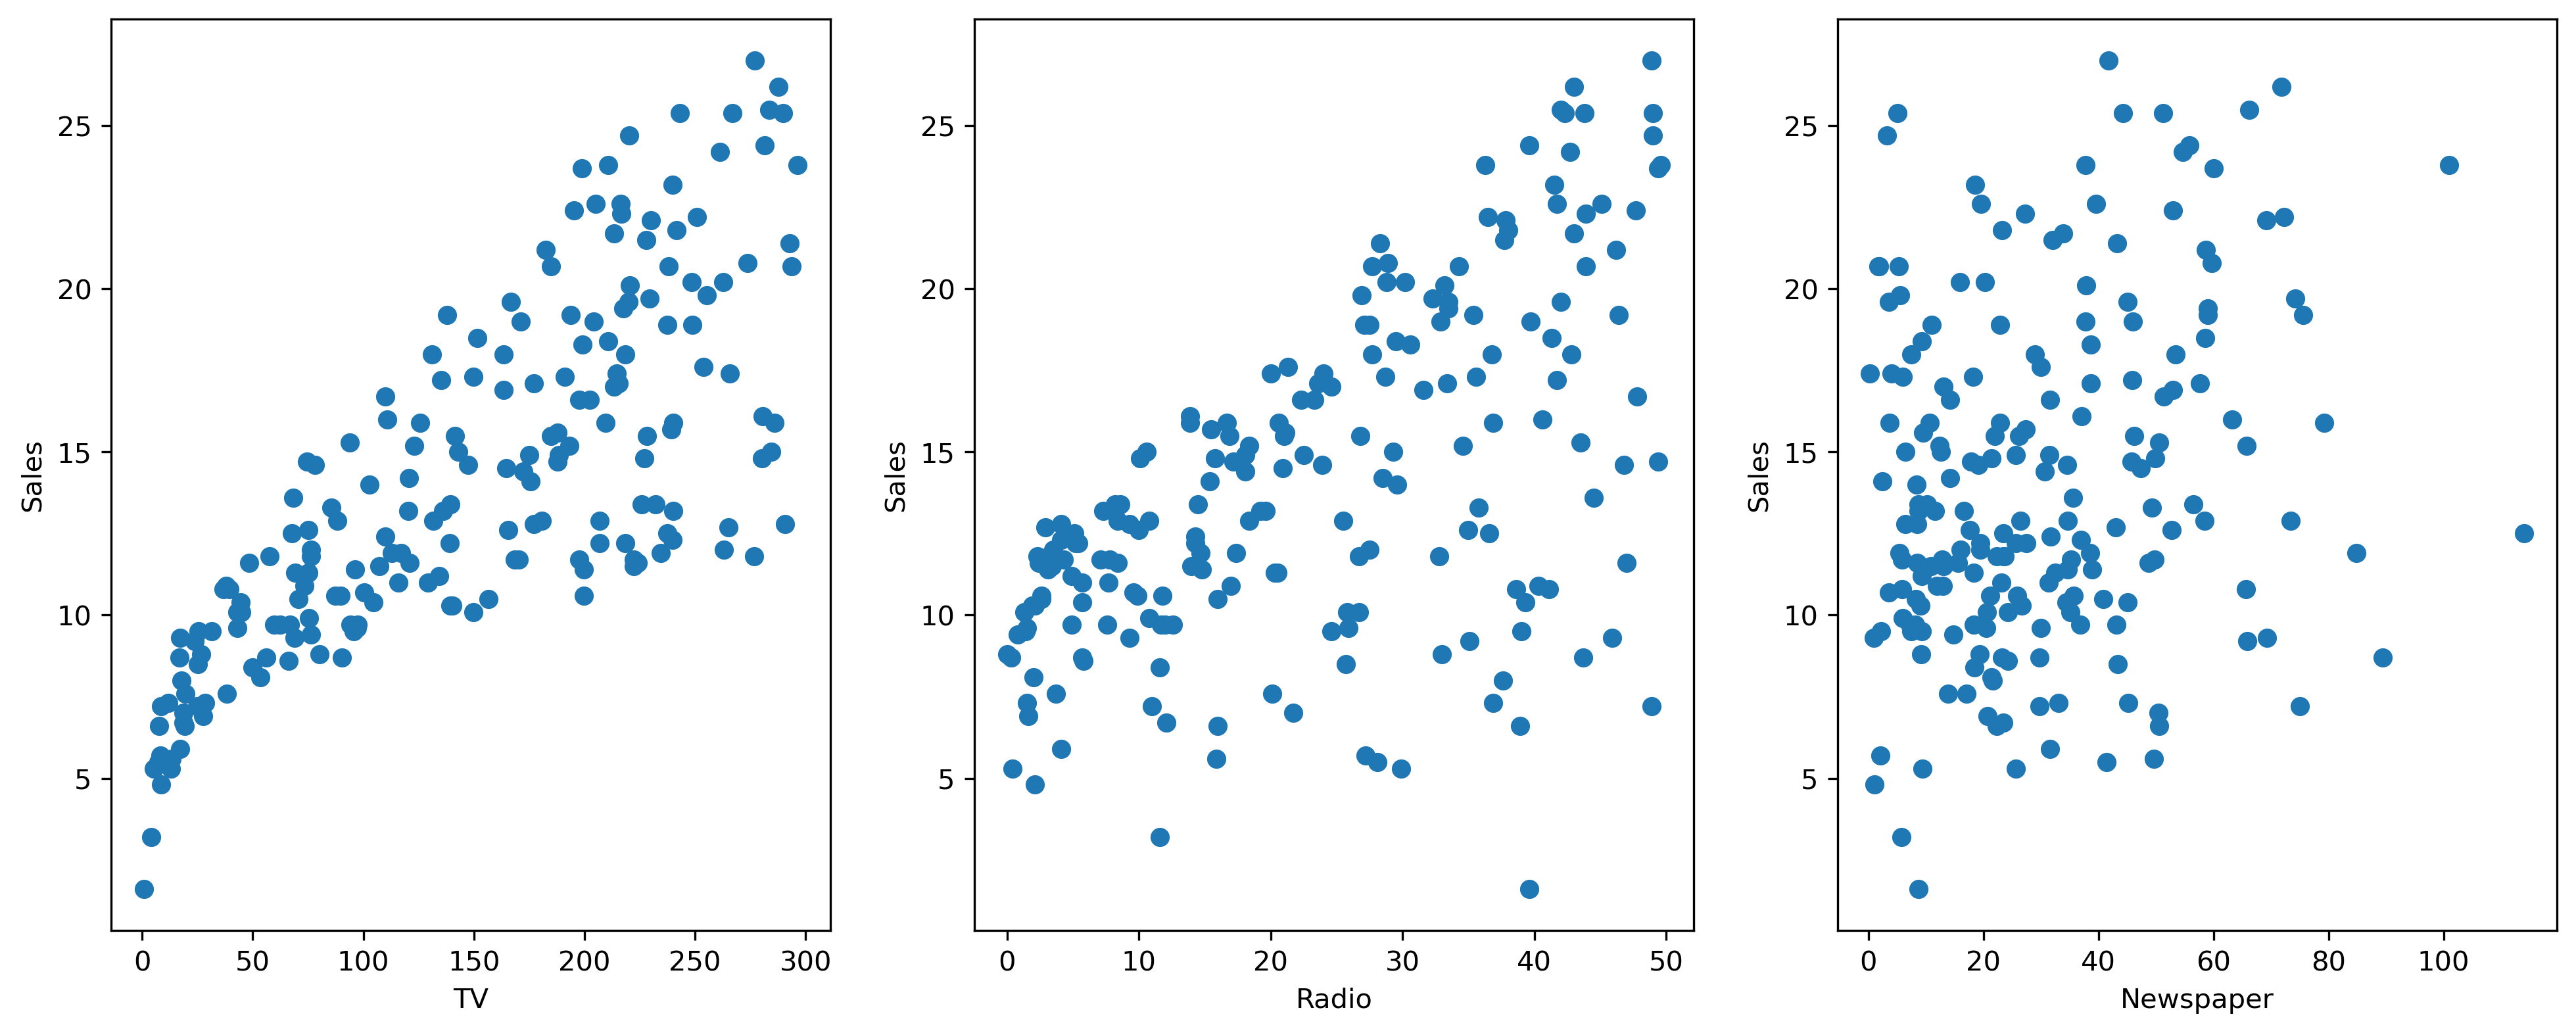

In [6]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize = (16, 6), dpi = 300)
ax[0].plot(df['TV'], df['Sales'], 'o')
ax[0].set_ylabel("Sales")
ax[0].set_xlabel("TV")

ax[1].plot(df['Radio'], df['Sales'], 'o')
ax[1].set_ylabel("Sales")
ax[1].set_xlabel("Radio")

ax[2].plot(df['Newspaper'], df['Sales'], 'o')
ax[2].set_ylabel("Sales")
ax[2].set_xlabel("Newspaper")                 

In [7]:
X = df.drop(['Sales'], axis = 1)
X

,TV,Radio,Newspaper
1,230.1,37.8,69.2
2,44.5,39.3,45.1
3,17.2,45.9,69.3
4,151.5,41.3,58.5
5,180.8,10.8,58.4
...,...,...,...
196,38.2,3.7,13.8
197,94.2,4.9,8.1
198,177.0,9.3,6.4
199,283.6,42.0,66.2


In [8]:
y = df['Sales']
y

1      22.1
2      10.4
3       9.3
4      18.5
5      12.9
       ... 
196     7.6
197     9.7
198    12.8
199    25.5
200    13.4
Name: Sales, Length: 200, dtype: float64

### Spiltting the data

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [11]:
X_train

,TV,Radio,Newspaper
86,193.2,18.4,65.7
184,287.6,43.0,71.8
128,80.2,0.0,9.2
54,182.6,46.2,58.7
101,222.4,4.3,49.8
...,...,...,...
64,102.7,29.6,8.4
71,199.1,30.6,38.7
82,239.8,4.1,36.9
12,214.7,24.0,4.0


### Creating a model or estimator

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
model = LinearRegression()

In [14]:
model.fit(X_train, y_train)

LinearRegression()

In [15]:
test_predictions = model.predict(X_test)

### find mean error to chech whether the prediction is accurate

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [17]:
mean_absolute_error(y_test, test_predictions)

1.213745773614481

In [19]:
mean_squared_error(y_test, test_predictions)

2.2987166978863796

In [20]:
root_mean_squared_error = np.sqrt(mean_squared_error(y_test, test_predictions))
root_mean_squared_error

np.float64(1.5161519375993884)

### Checking if linear regression was actually a good thing to use or not.
### Basically the residuals should be randomly distributed and have a normal distribution

In [21]:
test_residuals = y_test - test_predictions

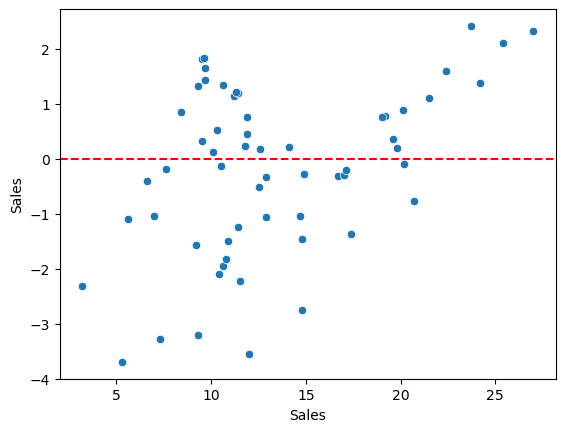

In [28]:
sns.scatterplot(x = y_test, y = test_residuals)
plt.axhline(y = 0, color = 'red', ls = '--')
# it should look random
# have no lines or curve patternb

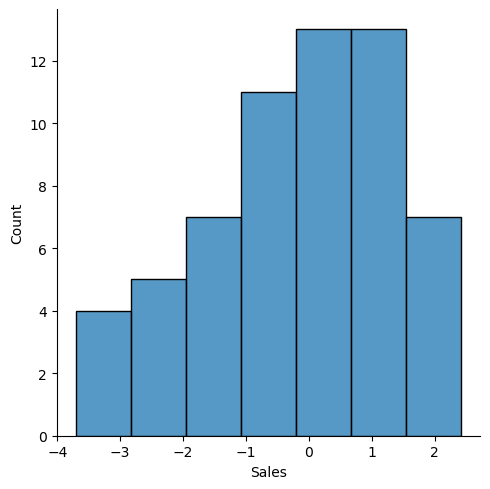

In [30]:
sns.displot(x = test_residuals)

### Deploying the model

In [31]:
final_model = LinearRegression()

In [32]:
final_model.fit(X, y) # we are using the entire data as from the testing we concluded that it is a good model to use

LinearRegression()

In [33]:
final_model.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

In [34]:
#  beta values of the below 3 cols
X

,TV,Radio,Newspaper
1,230.1,37.8,69.2
2,44.5,39.3,45.1
3,17.2,45.9,69.3
4,151.5,41.3,58.5
5,180.8,10.8,58.4
...,...,...,...
196,38.2,3.7,13.8
197,94.2,4.9,8.1
198,177.0,9.3,6.4
199,283.6,42.0,66.2


In [35]:
from joblib import dump, load

In [36]:
dump(final_model, 'finasl_sales_model.joblib')

['finasl_sales_model.joblib']

In [37]:
loaded_model = load('finasl_sales_model.joblib')

In [38]:
# 129 TV, 22 Radio, 12 newspaper
campaign = [[129, 22, 12]]
loaded_model.predict(campaign)

C:\Users\shaha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([12.97773909])